In [20]:
from alerce.core import Alerce
from astropy.table import Table
import matplotlib.pyplot as plt
import pyvo as vo
import requests
import sqlalchemy as sa
import sys
import numpy as np
from astropy.coordinates import SkyCoord
from astropy import units as u
import re

In [4]:
alerce = Alerce()
alerce_tap = vo.dal.TAPService('https://tap.alerce.online/tap')

In [3]:
# ztf_objects = alerce.query_objects(
#     survey="ztf",
#     classifier="lc_classifier",
#     class_name="SN",
#     format="pandas"
# )
# print(ztf_objects)

In [4]:
# ob = alerce.query_object(oid="ZTF26aacextk", survey="ztf", format="pandas")
# ob

In [5]:
filename = "../Data/tns_Ic.csv"
sources = Table.read(filename, format="csv")
sources[0]

objid,name_prefix,name,ra,declination,redshift,typeid,type,reporting_groupid,reporting_group,source_groupid,source_group,discoverydate,discoverymag,discmagfilter,filter,reporters,time_received,internal_names,Discovery_ADS_bibcode,Class_ADS_bibcodes,creationdate,lastmodified
int64,str2,str8,float64,float64,float64,int64,str5,int64,str6,int64,str3,str23,float64,int64,str1,str419,str19,str72,str19,str61,str19,str19
204620,SN,2026hbn,200.457594138,-22.4762664881,0.023896,5,SN Ic,48,ZTF,48,ZTF,2026-03-21 10:33:40.000,20.3619,111,r,"Jesper Sollerman (SU), Christoffer Fremling (Caltech), Daniel Perley (LJMU), Theophile du Laz (Caltech) on behalf of ZTF",2026-03-24 10:43:58,"ZTF26aapgavf, GOTO26cjo, ATLAS26dip, BGEM J132149.82-222834.4, PS26bbi",2026TNSTR1267....1S,2026TNSCR1744....1S,2026-03-24 10:43:59,2026-04-20 17:23:08


In [6]:
ZTF_mask = sources["source_group"] == "ZTF"
ZTF = sources[ZTF_mask]

In [7]:
#ZTF["internal_names"][0][:12]
ZTF_obj_Ic = []
pattern = r"ZTF"
for obj in ZTF["internal_names"]:
    internal = obj.split(',')
    survay_name = [name for name in internal if re.search(pattern, name)]
    #print(survay_name)
    ZTF_obj_Ic.append(survay_name[0])

ZTF_obj_Ic = np.array(ZTF_obj_Ic)
print(ZTF_obj_Ic)

['ZTF26aapgavf' 'ZTF26aarkqap' 'ZTF20acwclnm' 'ZTF26aajnayv'
 'ZTF26aagrmky' 'ZTF25abyevmr' 'ZTF25achlrsy' 'ZTF25acffrxl'
 'ZTF25abvbjre' 'ZTF25abqvssg' 'ZTF25ablulax' 'ZTF25abmhftu'
 'ZTF25aawmdtp' 'ZTF25abztbug' 'ZTF25acfkoue' 'ZTF25aaupzsu'
 'ZTF25abzudli' 'ZTF25abvcnay' 'ZTF25abitcpd' 'ZTF25abqsbxy'
 'ZTF25abclliu' 'ZTF25abjiieo' 'ZTF25aaxsmkl' 'ZTF25aacdjzo'
 'ZTF25aayvwoc' 'ZTF25aayiimj' 'ZTF25aavozkg' 'ZTF25aavmuzl'
 'ZTF25aarxgcb' 'ZTF25aaovvcg' 'ZTF25aamhjku' 'ZTF25aadnogd'
 'ZTF25aaadytl' 'ZTF24abzmhtv' 'ZTF24abxxniy' 'ZTF24abyqzpi'
 'ZTF24absznoi' 'ZTF24abtnkbi' 'ZTF24abnafgr' 'ZTF24abqbyxd'
 'ZTF24abncuhj' 'ZTF24abnsght' 'ZTF24abikstg' 'ZTF24ablsxza'
 'ZTF24abhsqly' 'ZTF24abhhzrp' 'ZTF20acwcisk' 'ZTF20abznlzl'
 'ZTF21aaqzfpe' 'ZTF21aceaqct' 'ZTF22abexdnd' 'ZTF22abtecxe'
 'ZTF23aaaznjk' 'ZTF23abdyhav' 'ZTF23abjjzlo' 'ZTF22abztcly'
 'ZTF24aayimjt' 'ZTF24aazmqbf' 'ZTF24aaxjjmx' 'ZTF24aayikbu'
 'ZTF24aawjwxx' 'ZTF24aawtoiv' 'ZTF24aakzmiu' 'ZTF24aateouu'
 'ZTF24aaeekei' 'ZTF24aa

In [35]:
light = alerce.query_forced_photometry(ZTF_obj_Ic[0], format="json")

In [39]:
light[0]
#plt.scatter(light["detections"])

{'candid': 'ZTF26aapgavf3369376053715',
 'tid': 'ztf',
 'pid': 3369376053715,
 'oid': 'ZTF26aapgavf',
 'mjd': 61123.3760532001,
 'fid': 1,
 'ra': 200.4576303,
 'e_ra': None,
 'dec': -22.4763175,
 'e_dec': None,
 'mag': 19.697500228881836,
 'e_mag': 0.08368796855211258,
 'mag_corr': None,
 'e_mag_corr': None,
 'e_mag_corr_ext': None,
 'isdiffpos': 1,
 'corrected': False,
 'dubious': False,
 'parent_candid': 3399289073715015001,
 'has_stamp': False,
 'rcid': 37,
 'magzpscirms': 0.030016399919986725,
 'distnr': 4.4266839027404785,
 'rfid': 272120137,
 'clrcoeff': -0.05113479867577553,
 'ranr': 200.45814514160156,
 'sciinpseeing': 2.232800006866455,
 'clrcounc': 1.2989299648324959e-05,
 'decnr': -22.47518539428711,
 'scibckgnd': 301.4590148925781,
 'exptime': 30.0,
 'magnr': 18.04400062561035,
 'scisigpix': 7.222990036010742,
 'adpctdif1': 0.10548300296068192,
 'sigmagnr': 0.05999999865889549,
 'magzpsci': 26.140499114990234,
 'adpctdif2': 0.10003700107336044,
 'chinr': 5.136000156402588,


<ErrorbarContainer object of 3 artists>

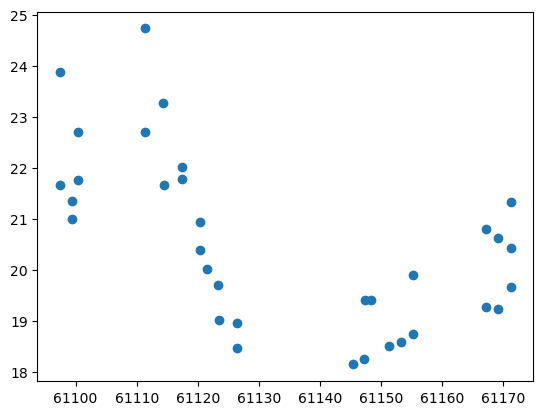

In [47]:
time = [obs["mjd"] for obs in light]
mag = [obs["mag"] for obs in light]
error = [obs["e_mag"] for obs in light]

plt.errorbar(time, mag, fmt='o')#, yerr=error)